In [1]:
import methylseqnet
from dimelo import parse_bam, load_processed, plot_enrichment_profile, plot_reads
import pysam
import numpy as np
from matplotlib import pyplot as plt

cuda is available  False
device for training cpu
PATH does not include the conda environment /bin folder. Adding /global/home/users/dixonluinenburg/.conda/envs/methylseqnet/bin.
PATH is now /global/home/users/dixonluinenburg/.conda/envs/methylseqnet/bin:/global/software/sl-7.x86_64/modules/langs/python/3.10/bin:/global/software/sl-7.x86_64/modules/tools/sq/0.1.0/bin:/global/software/sl-7.x86_64/modules/tools/emacs/25.1/bin:/global/software/sl-7.x86_64/modules/tools/vim/7.4/bin:/usr/local/bin:/bin:/usr/bin:/usr/local/sbin:/usr/sbin:/global/home/groups/allhands/bin:/global/home/users/dixonluinenburg/bin
modkit found with expected version 0.2.4


In [2]:
################################################################
# Specify filepaths
################################################################

genome_path = '/clusterfs/nilah/oberon/jupyter/chm13.draft_v1.0.fasta'

hia_bam_filepath = '/clusterfs/nilah/ayesha/dimelo/prod_free_Hia5_mod_mappings.sorted.bam'

combined_bam_filepath = '/clusterfs/nilah/oberon/downloads/prod_CTCF_winnowmap_guppy_merge.sorted.bam'
megalodon_bam_filepath = '/clusterfs/nilah/oberon/datasets/deep_ctcf/deep_ctcf_mod_mappings_merge.retagged.sorted.bam'
cpg_bam_filepath = '/clusterfs/nilah/oberon/datasets/deep_ctcf/deep_ctcf_CpG_mod_mappings.retagged.sorted.bam'


###########################################################################
# Load sequencing, reference, variant, genomic track, and liftover files
###########################################################################
combined = pysam.AlignmentFile(combined_bam_filepath,'rb')
megalodon = pysam.AlignmentFile(megalodon_bam_filepath,'rb')
hia5 = pysam.AlignmentFile(hia_bam_filepath,'rb')
cpg = pysam.AlignmentFile(cpg_bam_filepath,'rb')
genome = pysam.FastaFile(genome_path)

In [41]:
chip_bedfile = '/clusterfs/nilah/oberon/datasets/ctcf_peaks/ENCFF797SDL.chm13v1.0.bed'
from collections import defaultdict
chip_peaks_dict = defaultdict(list)
with open(chip_bedfile) as f:
    for line in f:
        chip_peaks_dict[line.split('\t')[0]].append(int(line.split('\t')[1]))
for chrom,peaks in chip_peaks_dict.items():
    print(chrom,len(peaks))

chr14 1412
chr1 3985
chrX 1484
chr15 1406
chr6 2436
chr16 1416
chr7 2029
chr3 2618
chr20 1162
chr12 2156
chr10 1952
chr8 1837
chr17 1936
chr9 1704
chr2 3200
chr19 1634
chr5 2194
chr21 387
chr11 2336
chr4 1961
chr22 816
chr13 925
chr18 875


In [3]:
print('cpg_only_megalodon')
for read in cpg.fetch('chr1',1000000,1000001):
    print(read.qname)
print('cpg_ma_megalodon')
for read in megalodon.fetch('chr1',1000000,1000001):
    print(read.qname)

cpg_only_megalodon
ff8235a0-7342-4de8-8958-ad207a7e316b
094af825-6264-4953-a2da-8c07d86e5a6f
1ef961e4-2f27-4be5-9f45-f01f00fa4299
b7cc83aa-5c46-4f19-a38a-bc6bdb5624d6
185929e2-ae0b-4dda-9f43-a49a2fe03b2f
90151c54-a2d6-4a76-9ef7-390c18020017
d421fd8f-6a48-499f-a882-5781960176b0
d49014d2-bdda-400a-9daf-60a62e481dc9
0f18c339-54fa-4a79-9677-071559533576
437de795-17b1-4676-8982-39e673ab5e73
cpg_ma_megalodon
3cbde546-e233-4130-a2a7-2bfd6b861b9a
17d6bcd9-deb6-43e6-8d32-f284ef2dea38
6351633d-e613-4261-a8f8-9d5d1ffa7c2a
ff8235a0-7342-4de8-8958-ad207a7e316b
e2aef839-767d-43b3-b1c6-c86f4b194710
18d945fa-2433-441e-906f-dc4a992375c7
a6fc026f-15ac-474a-9949-370e3cc0be42
ec9a569a-f3c8-410e-afca-d9f190700904
094af825-6264-4953-a2da-8c07d86e5a6f
1ef961e4-2f27-4be5-9f45-f01f00fa4299
b7cc83aa-5c46-4f19-a38a-bc6bdb5624d6
185929e2-ae0b-4dda-9f43-a49a2fe03b2f
1284f506-fd7f-4d30-86a0-5584fbc41ff8
9f9c56d7-4038-4b52-95b7-6dac2b923e96
8d01c12b-cb8f-4f58-a148-d99db1eb8cd8
c8e79516-38e7-486b-b7fd-4a0c504ec5bd
90

In [100]:
# region = 'chrX:130064000-130080000'
# region = 'chrX:0-100000000'
# region = 'chr1:206586177-206586178' #this is for t2t v1.1 cd55! not v1.0
# region = 'chr1:206586331-206586361' #cd55 tss t2t v1.0

In [106]:
# mA_pileup, _ = parse_bam.pileup(
#     input_file = megalodon_bam_filepath,
#     output_name = 'mA_bam_tss',
#     ref_genome = genome_path,
#     regions = region,
#     motifs = ['A,0','CG,0'],
#     thresh = 190,
#     window_size = 10000,
#     # override_checks = True,
# )

No output directory provided, using input directory /clusterfs/nilah/oberon/datasets/deep_ctcf
No specified number of cores requested. 32 available on machine, allocating all.
Modification threshold of 190 assumed to be for range 0-255. 190/255=0.7450980392156863 will be sent to modkit.


          | Preprocessing   0% | 00:00

          | Processing deep_ctcf_mod_mappings_merge.retagged.sorted.bam   0% | 00:00<?

          |    0%

In [81]:
# cpg_pileup, _ = parse_bam.pileup(
#     input_file = cpg_bam_filepath,
#     output_name = 'cpg_bam_whole_genome',
#     ref_genome = genome_path,
#     # regions = region,
#     motifs = ['A,0','CG,0'],
#     thresh = 190,
#     # window_size = None,
#     # override_checks = True,
# )


Do you expect this file to contain these modifications? parse_bam is looking for ['A,0', 'CG,0'] but for ['A'] found only found [].

Consider passing only the motifs and mod codes (e.g. m,h,a) that you expect to be present in your file. 
You can use modkit adjust-mods --convert <CONVERT> <CONVERT> [OPTIONS] <IN_BAM> <OUT_BAM> to update or consolidate mod codes.
See https://github.com/nanoporetech/modkit/blob/master/book/src/advanced_usage.md
                    
No output directory provided, using input directory /clusterfs/nilah/oberon/datasets/deep_ctcf
No specified number of cores requested. 32 available on machine, allocating all.
Modification threshold of 190 assumed to be for range 0-255. 190/255=0.7450980392156863 will be sent to modkit.


          | Preprocessing   0% | 00:00

          | Processing deep_ctcf_CpG_mod_mappings.retagged.sorted.bam   0% | 00:00<?

          |    0%

In [4]:
# print(cpg_pileup)
cpg_pileup = '/clusterfs/nilah/oberon/datasets/deep_ctcf/cpg_bam_whole_genome/pileup.sorted.bed.gz'
mA_pileup = '/clusterfs/nilah/oberon/datasets/deep_ctcf/allcontext_bam_whole_genome/pileup.sorted.bed.gz'

In [51]:
# cpg_extract,_ = parse_bam.extract(
#     input_file = cpg_bam_filepath,
#     output_name = 'imprint_region',
#     ref_genome = genome_path,
#     regions = region,
#     motifs = ['A,0','CG,0'],
#     thresh = 190,
#     window_size = 2000,
#     # override_checks = True,
# )


Do you expect this file to contain these modifications? parse_bam is looking for ['A,0', 'CG,0'] but for ['A'] found only found [].

Consider passing only the motifs and mod codes (e.g. m,h,a) that you expect to be present in your file. 
You can use modkit adjust-mods --convert <CONVERT> <CONVERT> [OPTIONS] <IN_BAM> <OUT_BAM> to update or consolidate mod codes.
See https://github.com/nanoporetech/modkit/blob/master/book/src/advanced_usage.md
                    
No output directory provided, using input directory /clusterfs/nilah/oberon/datasets/deep_ctcf
No specified number of cores requested. 32 available on machine, allocating all.
Modification threshold of 190 assumed to be for range 0-255. 190/255=0.7450980392156863 will be sent to modkit.


          | Preprocessing   0% | 00:00

          | Processing deep_ctcf_CpG_mod_mappings.retagged.sorted.bam   0% | 00:00<?

          |    0%

          | Transferring 0 from reads.A,0.txt into reads.combined_basemods.h5, new size 0   0% | 00:00<?

          | Preprocessing   0% | 00:00

          | Processing deep_ctcf_CpG_mod_mappings.retagged.sorted.bam   0% | 00:00<?

          |    0%

          | Transferring 11 from reads.CG,0.txt into reads.combined_basemods.h5, new size 11   0% | 00:00<?

In [13]:
# region = 'chr1:206586331-206586361' #cd55 tss t2t v1.0
# mod_vector,val_vector = load_processed.pileup_vectors_from_bedmethyl(
#     bedmethyl_file = cpg_pileup ,
#     regions = region,
#     window_size = 10000000,
#     motif='CG,0',
# )
# mod_vector_allcontext,val_vector_allcontext = load_processed.pileup_vectors_from_bedmethyl(
#     bedmethyl_file = mA_pileup ,
#     regions = region,
#     window_size = 10000000,
#     motif='CG,0',
# )

In [14]:
print('overall:',np.sum(mod_vector)/np.sum(val_vector))
print('overall:',np.sum(mod_vector_allcontext)/np.sum(val_vector_allcontext))
# for chunk in range(0,1000):
#     print(f'chunk {chunk} of 1000:',np.sum(mod_vector[chunk*100000:(chunk+1)*100000])/np.sum(val_vector[chunk*100000:(chunk+1)*100000]))

overall: 0.5356663694018633
overall: 0.11996858099925664


Text(0.5, 1.0, 'deep ctcf chr1:206586331-206586361 +-3000bp no smoothing')

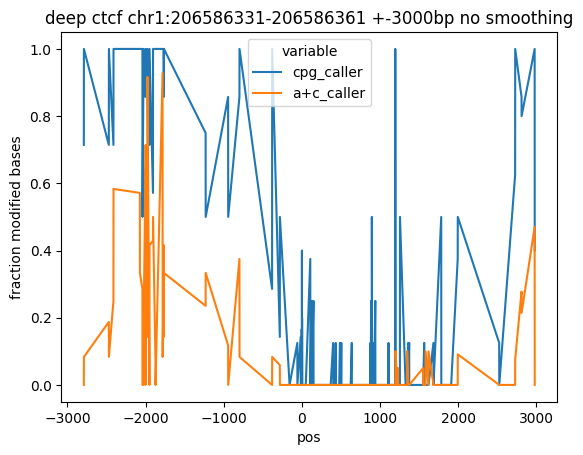

In [72]:

window_size = 3000
plot_enrichment_profile.plot_enrichment_profile(
    mod_file_names = [cpg_pileup,mA_pileup],
    regions_list = [region,region],
    motifs=['CG,0','CG,0'],
    sample_names = ['cpg_caller','a+c_caller'],
    window_size = window_size,
    single_strand = False,
    regions_5to3prime = False,
    smooth_window = None,
)
plt.title(f'deep ctcf {region} +-{window_size}bp no smoothing')

In [95]:
# plot_reads.plot_reads(
#     mod_file_name = cpg_extract,
#     regions = region,
#     motifs = ['CG,0'],
#     window_size = 5000,
#     # single_strand: bool = False,
#     # regions_5to3prime: bool = False,
#     sort_by = ['read_start'],
#     # thresh: float | None = None,
#     relative = True,
#     s=10,
# )

In [15]:
mod_vector_allcontext,val_vector_allcontext = load_processed.pileup_vectors_from_bedmethyl(
    bedmethyl_file = mA_pileup ,
    regions = 'chr1:0-250000000',
    motif='A,0',
)

In [49]:
# Reshape the vector into chunks of 128 (make sure the total length is a multiple of 128)
n_chunks = len(mod_vector_allcontext) // 128
reshaped_mod_vector = mod_vector_allcontext[:n_chunks * 128].reshape(n_chunks, 128)
reshaped_val_vector = val_vector_allcontext[:n_chunks * 128].reshape(n_chunks, 128)

# Sum across each row to get the sums of each chunk
mod_chunk_sums = reshaped_mod_vector.sum(axis=1)
val_chunk_sums = reshaped_val_vector.sum(axis=1)

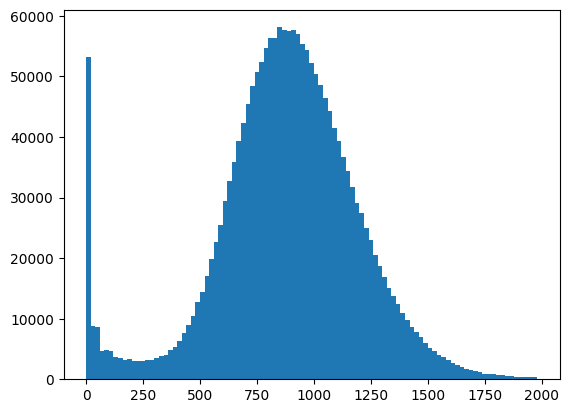

/tmp/ipykernel_142444/57193800.py:3: RuntimeWarning: invalid value encountered in divide
  plt.hist(mod_chunk_sums/val_chunk_sums)


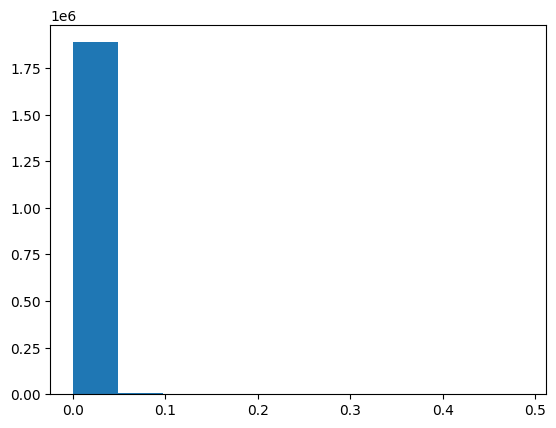

In [50]:
plt.hist(val_chunk_sums,bins=np.arange(0,2000,20))
plt.show()
plt.hist(mod_chunk_sums/val_chunk_sums)
plt.show()

In [69]:
call_thresh = 0.05
nearby_range = 512
chr1_peaks_called = (mod_chunk_sums/val_chunk_sums)>call_thresh
n = 5

# Create a kernel of size 2n+1
kernel = np.ones(2*n + 1)

# Apply convolution
convolved = np.convolve(chr1_peaks_called, kernel, mode='same')

# Find indices where the convolution result is zero
result_indices = np.where(convolved == 0)[0]

# Count of such elements
count_zeros = len(result_indices)
print(count_zeros)
print(np.sum(chr1_peaks_called))
print(len(chr1_peaks_called))
found = 0
unfound = 0
overfound = 0
for peak in chip_peaks_dict['chr1']:
    nearby_count = np.sum(chr1_peaks_called[peak//128-nearby_range//128:peak//128+nearby_range//128])
    if nearby_count>1:
        found+=1
        overfound+=nearby_count-1
    elif nearby_count>0:
        found+=1
    else:
        unfound+=1
    
print(overfound,found,unfound)

1882778
11736
1953125
1917 2356 1629


/tmp/ipykernel_142444/611715227.py:3: RuntimeWarning: invalid value encountered in divide
  chr1_peaks_called = (mod_chunk_sums/val_chunk_sums)>call_thresh


In [71]:
center_index = 3
context = 3
step = context*2 + 1
negative = 0
positive = 0
while center_index + context < len(chr1_peaks_called):
    if np.sum(chr1_peaks_called[center_index-context:center_index+context+1])==0:
        negative+=1
        center_index+=step
    else:
        positive+=np.sum(chr1_peaks_called[center_index-context:center_index+context+1])
        center_index+=step
print(positive,negative)

11736 272080


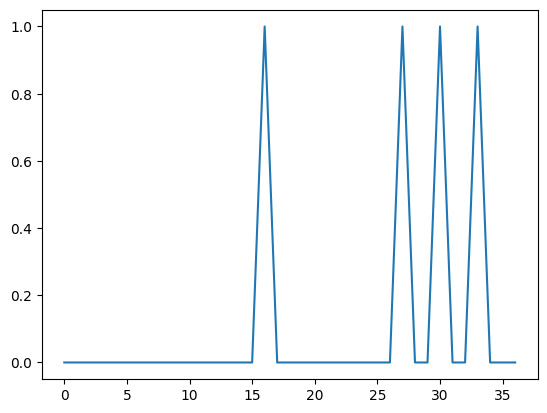

In [76]:
# regionX = 'chrX:130064000-130080000'
regionX = 'chr11:2086423-2091187'
mod_vector_chrX,val_vector_chrX = load_processed.pileup_vectors_from_bedmethyl(
    bedmethyl_file = mA_pileup ,
    regions = regionX,
    motif='A,0',
)
# Reshape the vector into chunks of 128 (make sure the total length is a multiple of 128)
n_chunks = len(mod_vector_chrX) // 128
reshaped_mod_vector_chrX = mod_vector_chrX[:n_chunks * 128].reshape(n_chunks, 128)
reshaped_val_vector_chrX = val_vector_chrX[:n_chunks * 128].reshape(n_chunks, 128)

# Sum across each row to get the sums of each chunk
mod_chunk_sums_chrX = reshaped_mod_vector_chrX.sum(axis=1)
val_chunk_sums_chrX = reshaped_val_vector_chrX.sum(axis=1)
plt.plot((mod_chunk_sums_chrX/val_chunk_sums_chrX)>0.05)

chr14 1412
chr1 3985
chrX 1484
chr15 1406
chr6 2436
chr16 1416
chr7 2029
chr3 2618
chr20 1162
chr12 2156
chr10 1952
chr8 1837
chr17 1936
chr9 1704
chr2 3200
chr19 1634
chr5 2194
chr21 387
chr11 2336
chr4 1961
chr22 816
chr13 925
chr18 875
